<div align = "center">
    <h1>London Crime & Deprivation Analysis</h1>   
</div>

I found during exploratory data analysis that not only did London report the most offences, but it also had a distinctive crime profile. Of the five most recorded offence subgroups, three were theft related offences - other theft offences, theft from the person and shoplifting. This suggested that theft-related crime may play a particularly important role in explaining crime patterns within London and motivated further investigation alongside deprivation data.

Import required libraries:

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import os

Load the datasets:

In [102]:
crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")

imd_df = pd.read_csv("clean_index_of_multiple_deprivation.csv")

imd_map = pd.read_csv(
    "2025_index_of_multiple_deprivation.csv",
)

Another team member has already done EDA on the deprivation dataset as part of the wider project. For this analysis only columns required to investigate the link between crime rates and deprivation within London are retained.

Filter the dataset to retain only London observations:

In [86]:
london_imd = imd_df[
    imd_df["ITL1"] == "London"
]

## Distribution Across London's Five ITL2 Regions

Before visualising deprivation, the number of observations in each ITL2 region was examined.

In [87]:
london_imd["ITL2"].value_counts()

ITL2
Inner London - East                   1305
Outer London - West and North West    1179
Outer London - East and North East    1073
Outer London - South                   776
Inner London - West                    661
Name: count, dtype: int64

## Average Deprivation by ITL2 Region

To compare deprivation across London's five ITL2 regions, average IMD rank and IMD decile values were calculated.

In [88]:
london_imd_summary = (
    london_imd
    .groupby("ITL2")
    .agg({
        "IMD Rank": "mean",
        "IMD Decile": "mean"
    })
    .reset_index()
)

london_imd_summary

,ITL2,IMD Rank,IMD Decile
0,Inner London - East,11228.959387,3.829885
1,Inner London - West,16841.357035,5.502269
2,Outer London - East and North East,15258.014911,5.017707
3,Outer London - South,20764.436856,6.636598
4,Outer London - West and North West,15592.934690,5.104326


How to interpret the IMD numbers: For **IMD Rank, the smaller the number the more deprived an area is**. Based on the data above, **Inner London East is the most deprived** ITL2 region in London, and **Outer London - South is the least deprived** ITL2 region in London. 

The **IMD Decile** categorises more broadly, deciles range from 1-10. **Decile 1** = Most deprived 10% of areas in England and **Decile 10** = Least deprived 10% of areas in England.



## Visualising Data at ITL2 Level

To understand deprivation at a broad regional level, the average IMD decile was calculated for each of London's five ITL2 regions.

The IMD dataset and boundary files use different column names for the LSOA identifier. The relevant columns were renamed to create a consistent join key and simplify subsequent analysis.

In [89]:
imd_map_clean = imd_map.rename(columns={
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})

In [90]:
imd_map_clean["ITL2"] = imd_df["ITL2"]

In [91]:
shp_files = [
    f for f in os.listdir("LB_shp")
    if f.endswith(".shp")
]

boroughs = []

for shp in shp_files:
    gdf = gpd.read_file(f"LB_shp/{shp}")
    boroughs.append(gdf)

london_boundaries = pd.concat(
    boroughs,
    ignore_index=True
)

In [92]:
london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

To provide a broad overview of deprivation across London, the average IMD decile was calculated for each of the five ITL2 regions. This allows deprivation patterns to be compared at a regional level before examining neighbourhood-level variation.

In [93]:
itl2_map = (
    london_map
    .dissolve(
        by="ITL2",
        aggfunc={
            "IMD Rank": "mean",
            "IMD Decile": "mean"
        }
    )
    .reset_index()
)

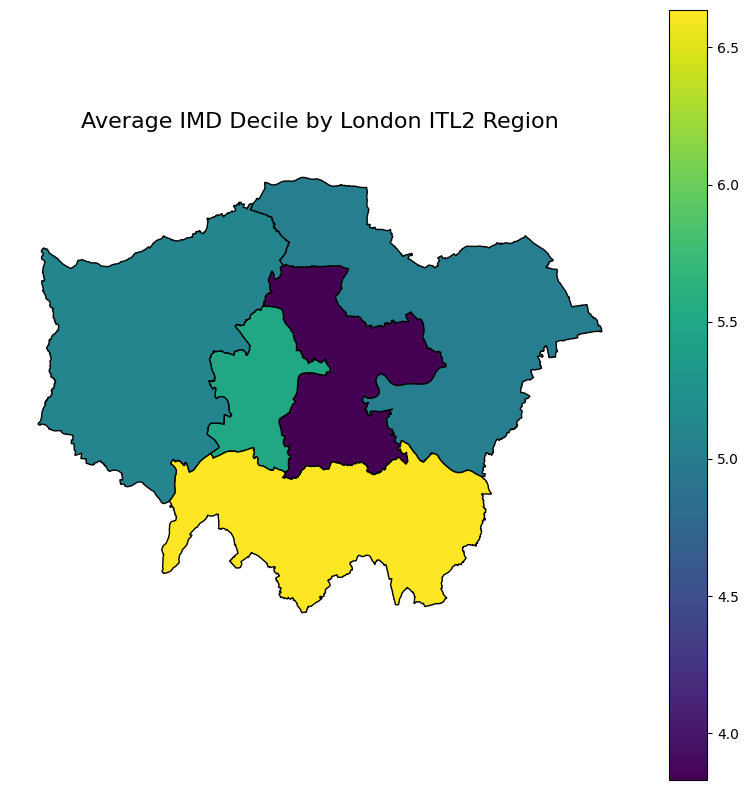

In [94]:
fig, ax = plt.subplots(figsize=(10, 10))

itl2_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

ax.set_title(
    "Average IMD Decile by London ITL2 Region",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()

At ITL2 level, London appears to exhibit a relatively straightforward deprivation pattern. Inner London - East has the lowest average IMD decile and is therefore the most deprived region on average, while Outer London - South has the highest average IMD decile and is the least deprived. However, these averages may conceal important variation within each region.

## Preparing the London crime data

In [103]:
london_crime = crime_df[
    crime_df["ITL1 region"] == "London"
]

In [96]:
london_crime_summary = (
    london_crime
    .groupby("ITL2 region")["Number of Offences"]
    .sum()
    .reset_index()
)

london_crime_summary

,ITL2 region,Number of Offences
0,"['Inner London - West', 'Inner London - East',...",943924
1,['Inner London - West'],9179


In [97]:
london_crime["ITL2 region"].unique()

<StringArray>
['['Inner London - West']', '['Inner London - West', 'Inner London - East', 'Outer London - East and North East', 'Outer London - South', 'Outer London - West and North West']']
Length: 2, dtype: str

The crime dataset does not contain separate crime totals for London’s five ITL2 regions. Instead, offences are recorded at police force level, which prevents a direct comparison between crime and deprivation at ITL2 level.


## Visualising Deprivation Data Across London

Although direct comparison between crime and deprivation was not possible, the ITL2 analysis suggested that regional averages may hide important local variation. To investigate this further, deprivation was examined at LSOA level.

To better understand how deprivation varies across London, a geographic visualisation was created. Choropleth maps are particularly useful for displaying regional differences because they allow patterns to be viewed spatially rather than as a simple ranking.

A choropleth map was preferred to a traditional bar chart because IMD Rank is an inverse measure of deprivation, where lower values indicate greater deprivation. While a bar chart could still be used, it may be less intuitive for readers, as taller bars would represent areas with lower levels of deprivation. A map provides a clearer visual representation of how deprivation is distributed across London.


## Creating a Choropleth Map of London Deprivation

## Preparing IMD Data for Mapping

The IMD dataset and boundary files use different column names for the LSOA identifier. The relevant columns were renamed to create a consistent join key and simplify subsequent analysis.

In [98]:
imd_map_clean = imd_map.rename(columns={
    "LSOA code (2021)": "lsoa21cd",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "IMD Rank",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA": "IMD Decile"
})

## Merging Boundary and Deprivation Data
The deprivation data was merged with the London boundary data using the LSOA code, creating a dataset suitable for geographic visualisation.

In [99]:
london_map = london_boundaries.merge(
    imd_map_clean,
    on="lsoa21cd",
    how="left"
)

## Creating a Choropleth Map of London Deprivation

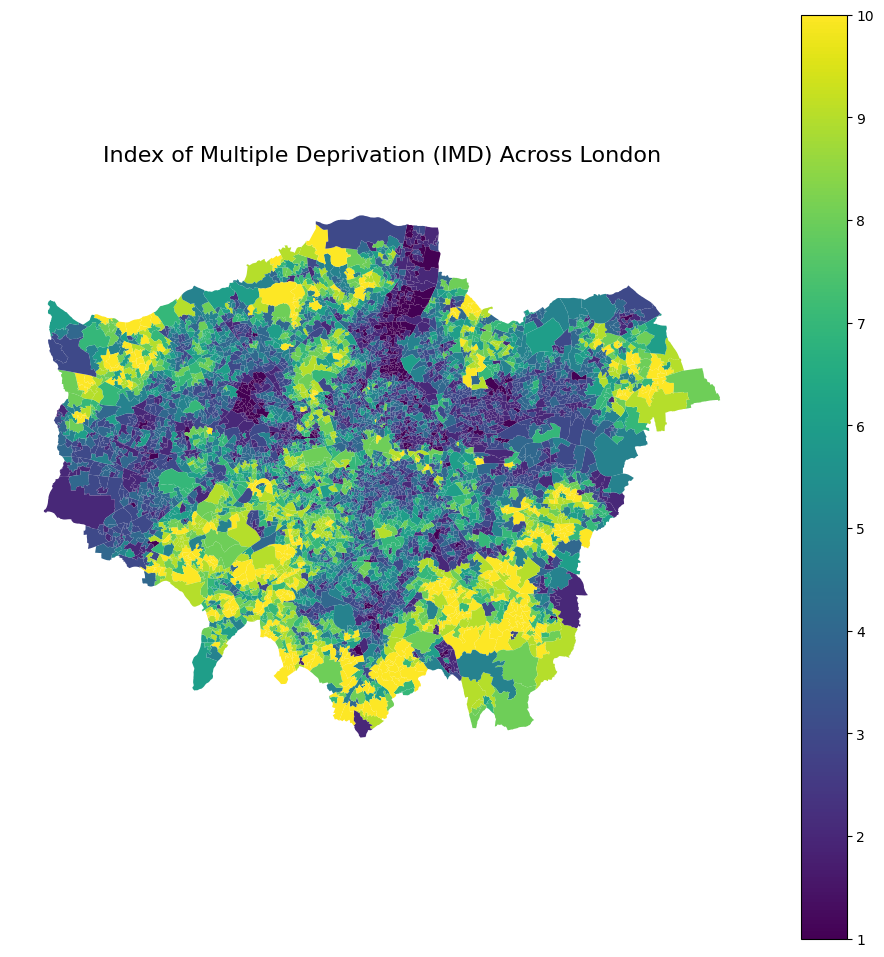

In [101]:
fig, ax = plt.subplots(figsize=(12, 12))

london_map.plot(
    column="IMD Decile",
    cmap="viridis",
    legend=True,
    linewidth=0,
    ax=ax
)

ax.set_title(
    "Index of Multiple Deprivation (IMD) Across London",
    fontsize=16,
    pad=20
)

ax.axis("off")

plt.show()

The choropleth map highlights substantial variation in deprivation across London. Areas with lower IMD deciles (shown in darker colours) are concentrated in several parts of Inner London, although deprivation is present throughout the capital. Areas with higher IMD deciles (shown in lighter colours) are more common in parts of Outer London. The map demonstrates that deprivation is not evenly distributed across London and varies considerably between neighbourhoods.